# Healthcare Diabetes

In [33]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

In [34]:
# Step 2: Load dataset
df = pd.read_csv("Healthcare-Diabetes.csv")

In [35]:
# View first 5 rows
df.head()

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,6,148,72,35,0,33.6,0.627,50,1
1,2,1,85,66,29,0,26.6,0.351,31,0
2,3,8,183,64,0,0,23.3,0.672,32,1
3,4,1,89,66,23,94,28.1,0.167,21,0
4,5,0,137,40,35,168,43.1,2.288,33,1


In [36]:
# Shape of dataset
df.shape

(2768, 10)

In [37]:
# Column names
df.columns

Index(['Id', 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
       'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [38]:
# Data types and null info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2768 entries, 0 to 2767
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        2768 non-null   int64  
 1   Pregnancies               2768 non-null   int64  
 2   Glucose                   2768 non-null   int64  
 3   BloodPressure             2768 non-null   int64  
 4   SkinThickness             2768 non-null   int64  
 5   Insulin                   2768 non-null   int64  
 6   BMI                       2768 non-null   float64
 7   DiabetesPedigreeFunction  2768 non-null   float64
 8   Age                       2768 non-null   int64  
 9   Outcome                   2768 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 216.4 KB


In [39]:
# Statistical summary
df.describe()

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000
mean,1384.500000,3.742775,121.102601,69.134393,20.824422,80.127890,32.137392,0.471193,33.132225,0.343931
std,799.197097,3.323801,32.036508,19.231438,16.059596,112.301933,8.076127,0.325669,11.777230,0.475104
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,692.750000,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.244000,24.000000,0.000000
50%,1384.500000,3.000000,117.000000,72.000000,23.000000,37.000000,32.200000,0.375000,29.000000,0.000000
75%,2076.250000,6.000000,141.000000,80.000000,32.000000,130.000000,36.625000,0.624000,40.000000,1.000000
max,2768.000000,17.000000,199.000000,122.000000,110.000000,846.000000,80.600000,2.420000,81.000000,1.000000


In [40]:
# Check missing values
df.isnull().sum()

Id                          0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [41]:
# Fill numeric missing values with median
for column in df.select_dtypes(include=np.number).columns:
    df[column].fillna(df[column].median(), inplace=True)

# Fill categorical missing values with mode
for column in df.select_dtypes(include='object').columns:
    df[column].fillna(df[column].mode()[0], inplace=True)

df.isnull().sum()

Id                          0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [42]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

In [43]:
# Remove duplicates
df.drop_duplicates(inplace=True)


In [44]:
df.shape

(2768, 10)

In [45]:
# Replace 0 with NaN for specific columns
columns_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns_with_zero:
    if col in df.columns:
        df[col] = df[col].replace(0, np.nan)

In [46]:
# Fill them with median
for col in columns_with_zero:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

df.describe()

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000
mean,1384.500000,3.742775,121.863439,72.385838,29.205925,140.669798,32.593895,0.471193,33.132225,0.343931
std,799.197097,3.323801,30.503499,11.988549,9.032220,82.887979,7.103462,0.325669,11.777230,0.475104
min,1.000000,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,692.750000,1.000000,99.000000,64.000000,25.000000,120.000000,27.575000,0.244000,24.000000,0.000000
50%,1384.500000,3.000000,117.000000,72.000000,29.000000,126.000000,32.400000,0.375000,29.000000,0.000000
75%,2076.250000,6.000000,141.000000,80.000000,32.000000,130.000000,36.625000,0.624000,40.000000,1.000000
max,2768.000000,17.000000,199.000000,122.000000,110.000000,846.000000,80.600000,2.420000,81.000000,1.000000


In [47]:
# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df.columns

Index(['id', 'pregnancies', 'glucose', 'bloodpressure', 'skinthickness',
       'insulin', 'bmi', 'diabetespedigreefunction', 'age', 'outcome'],
      dtype='object')

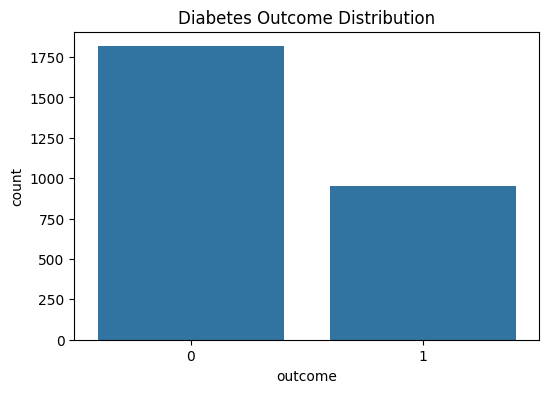

In [48]:
# Count Plot (Diabetes Outcome Distribution)----
plt.figure(figsize=(6,4))
sns.countplot(x='outcome', data=df)
plt.title("Diabetes Outcome Distribution")
plt.show()


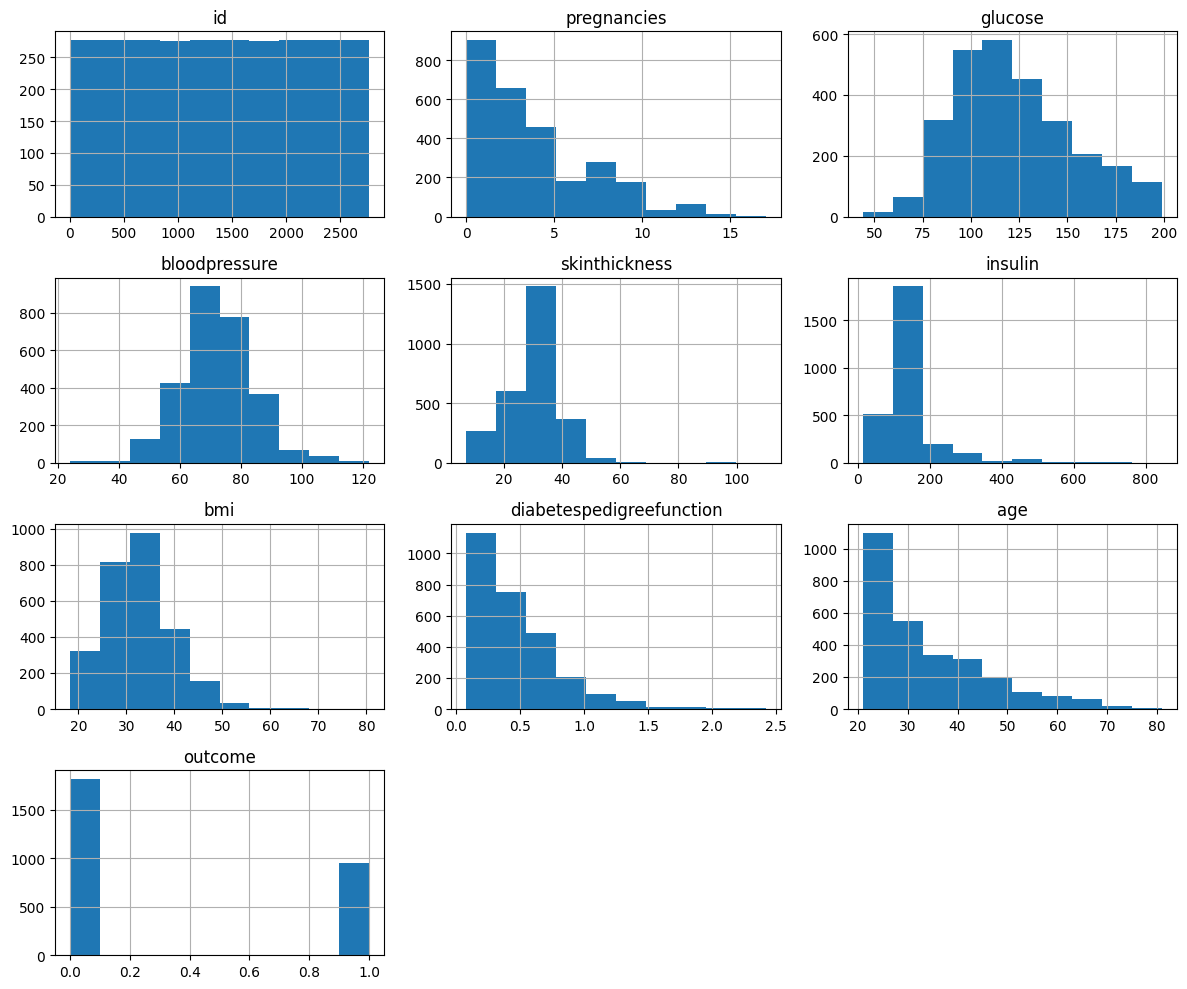

In [49]:
# Histogram of All Numerical Features
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

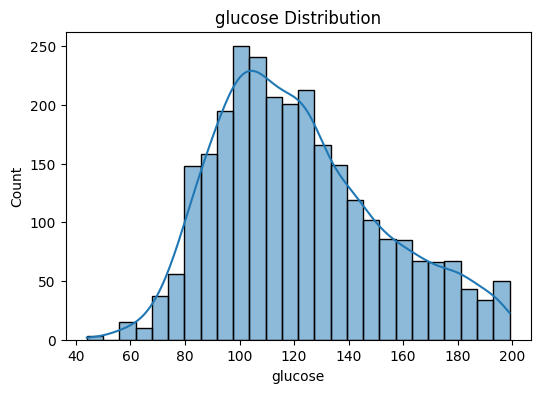

In [50]:
# Glucose Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['glucose'], kde=True)
plt.title("glucose Distribution")
plt.show()

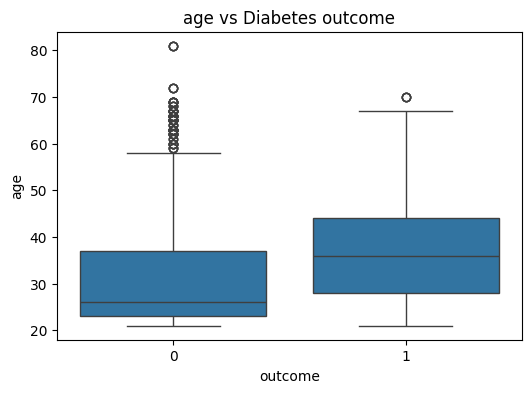

In [51]:
# Age vs Outcome
plt.figure(figsize=(6,4))
sns.boxplot(x='outcome', y='age', data=df)
plt.title("age vs Diabetes outcome")
plt.show()

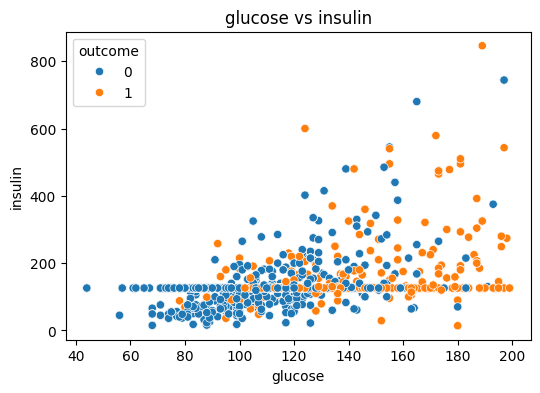

In [52]:
# Glucose vs Insulin Scatter Plot
plt.figure(figsize=(6,4))
sns.scatterplot(x='glucose', y='insulin', hue='outcome', data=df)
plt.title("glucose vs insulin")
plt.show()

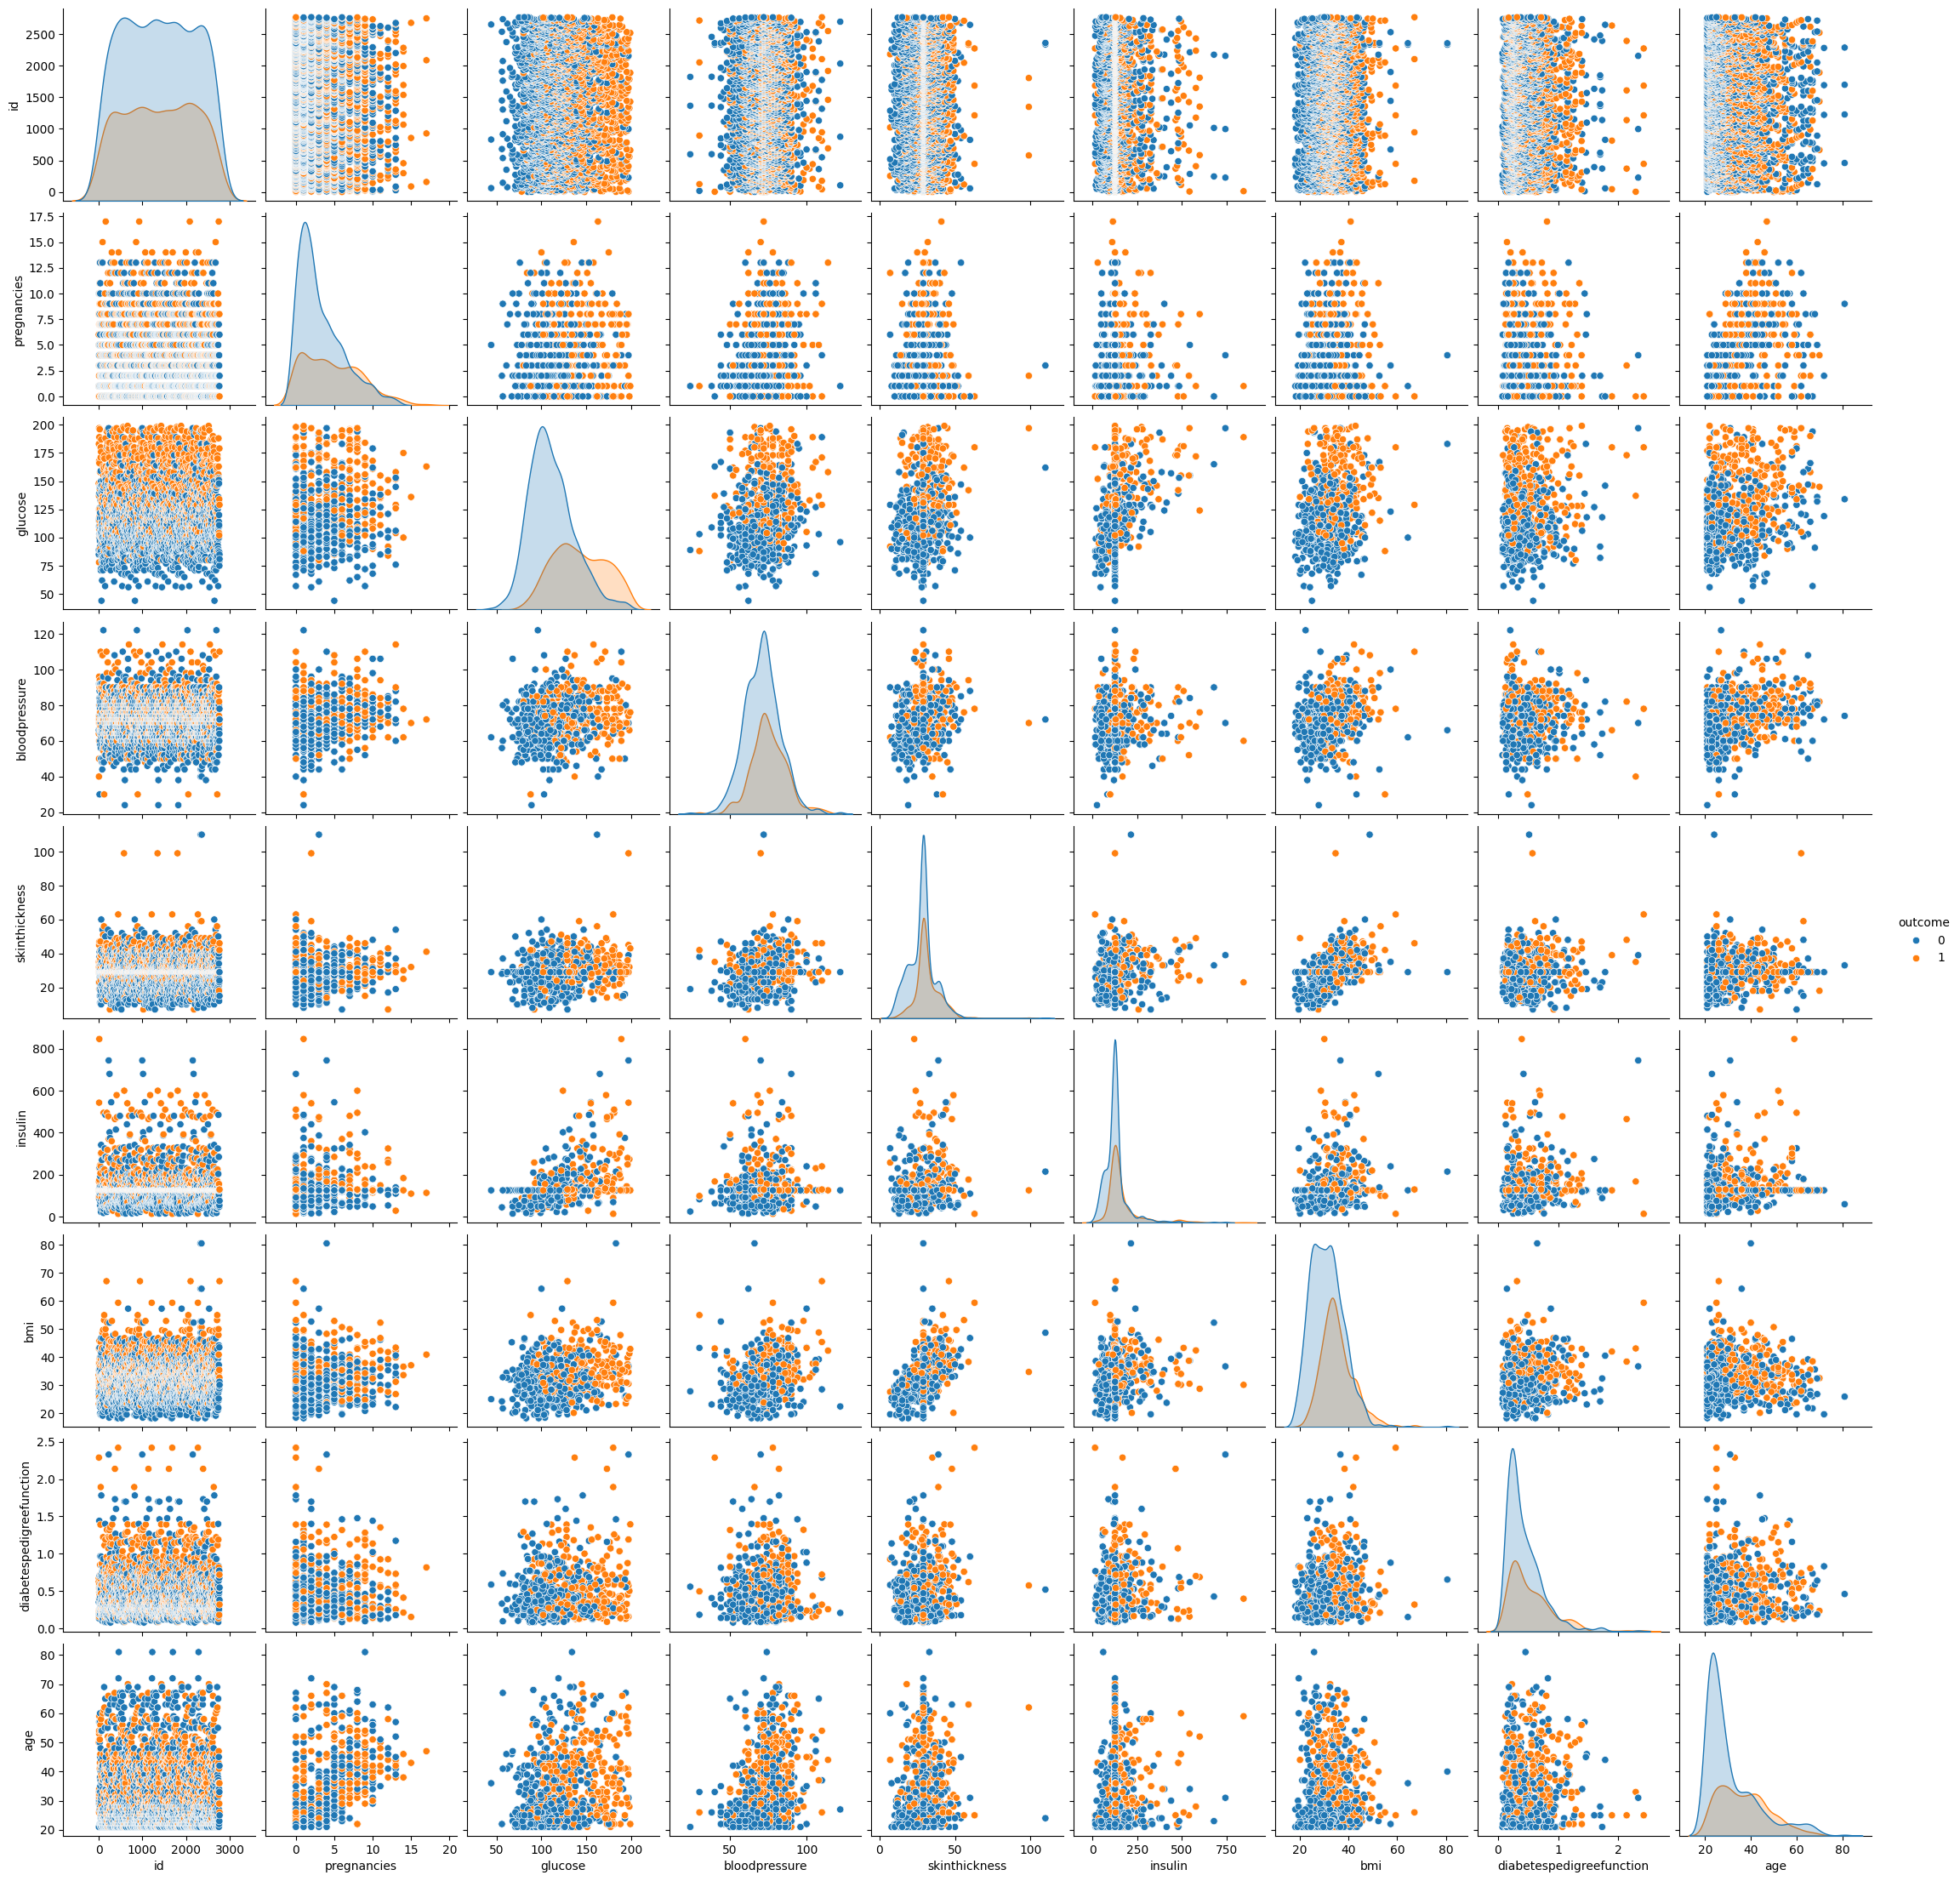

In [53]:
# Pairplot
sns.pairplot(df, hue='outcome')
plt.show()

In [54]:
#  Convert Outcome to category if exists
if 'outcome' in df.columns:
    df['outcome'] = df['outcome'].astype('category')

In [55]:
# saved clean data
df.to_csv("Healthcare-Diabetes-Cleaned.csv", index=False)

# code for ms SQL

In [56]:
import pyodbc
import pandas as pd

In [57]:
pyodbc.drivers()

['SQL Server',
 'ODBC Driver 17 for SQL Server',
 'ODBC Driver 18 for SQL Server',
 'Microsoft Access Driver (*.mdb, *.accdb)',
 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)',
 'Microsoft Access Text Driver (*.txt, *.csv)',
 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']

In [58]:
import pyodbc

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=LAPTOP-8964GNOA\\SQLEXPRESS;"
    "DATABASE=Healthcare_diabetes;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

cursor = conn.cursor()
print("✅ Connected successfully")

✅ Connected successfully


In [59]:
df.head()

,id,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
0,1,6,148.0,72.0,35.0,126.0,33.6,0.627,50,1
1,2,1,85.0,66.0,29.0,126.0,26.6,0.351,31,0
2,3,8,183.0,64.0,29.0,126.0,23.3,0.672,32,1
3,4,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,5,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [60]:
df.columns

Index(['id', 'pregnancies', 'glucose', 'bloodpressure', 'skinthickness',
       'insulin', 'bmi', 'diabetespedigreefunction', 'age', 'outcome'],
      dtype='object')

In [61]:
create_table_query = """
IF NOT EXISTS (
    SELECT * FROM sys.tables WHERE name = 'healthcare_diabetes'
)
BEGIN
    CREATE TABLE healthcare_diabetes (
        id INT IDENTITY(1,1) PRIMARY KEY,
        pregnancies INT,
        glucose INT,
        bloodpressure INT,
        skinthickness INT,
        insulin INT,
        bmi FLOAT,
        diabetespedigreefunction FLOAT,
        age INT,
        outcome INT
    );
END
"""
cursor.execute(create_table_query)
conn.commit()

print("Table created successfully!")

Table created successfully!


In [62]:
insert_query = """
INSERT INTO healthcare_diabetes
(pregnancies, glucose, bloodpressure, skinthickness,
 insulin, bmi, diabetespedigreefunction, age, outcome)
VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
"""

In [63]:
for index, row in df.iterrows():
    cursor.execute(insert_query,
                   int(row['pregnancies']),
                   int(row['glucose']),
                   int(row['bloodpressure']),
                   int(row['skinthickness']),
                   int(row['insulin']),
                   float(row['bmi']),
                   float(row['diabetespedigreefunction']),
                   int(row['age']),
                   int(row['outcome'])
                   )

conn.commit()

print("Data inserted successfully!")

Data inserted successfully!
